Import des Bibliothèques 

In [147]:
!pip install pytz
!pip install matplotlib
!pip install xlrd
!pip install chardet



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/531.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/531.0 kB ? eta -:--:--
   ---------------------------------------- 531.0/531.0 kB 11.4 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Ajouter les fonction de data cleaning dans cette feuille 

#Bibliothèques 
import pandas as pd 
import numpy as np 
from io import StringIO
from zoneinfo import ZoneInfo
import os
import matplotlib.pyplot as plt
import chardet

print ("librairies importées")


librairies importées


Code Ana 

Nettoyage des données day ahead prices pour 2024 2025

[Day-ahead Prices_2024-2025.csv] ✅ Aucune valeur manquante.
Dimensions : (8784, 3)
count    8784.000000
mean       58.019464
std        40.658254
min       -87.290000
25%        25.507500
50%        58.810000
75%        86.537500
max       284.210000
Name: Day-ahead Price (EUR/MWh), dtype: float64


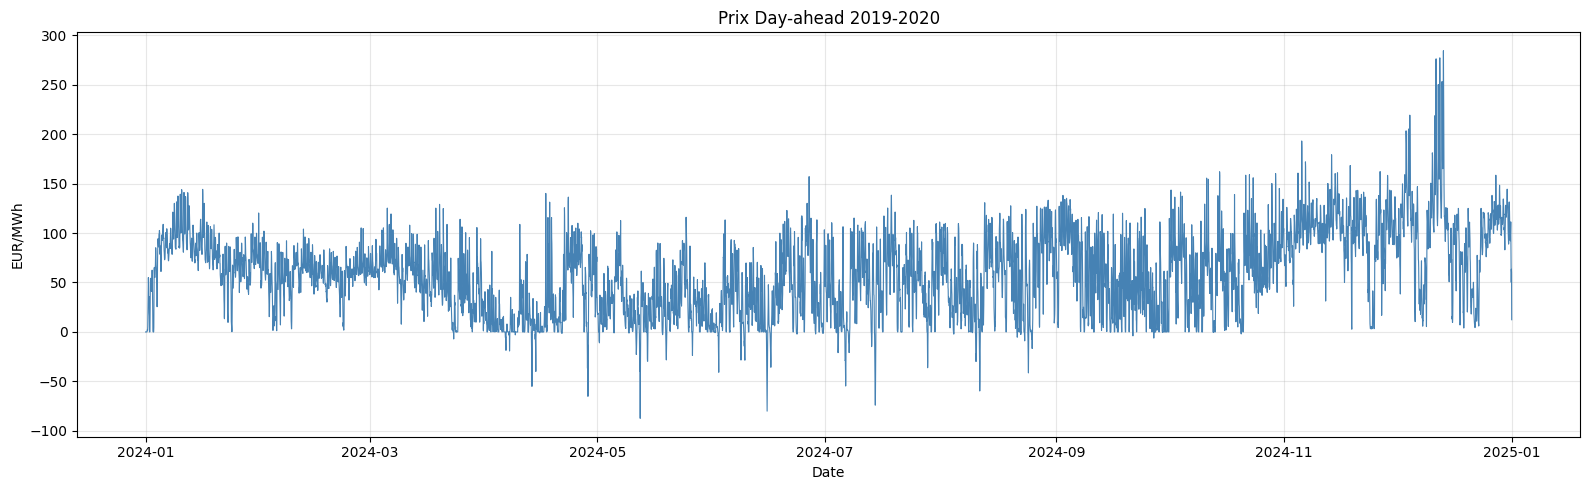

In [2]:
def harmonize_data_DayAhead_price(chemin_fichier):
    try:
        with open(chemin_fichier, 'r', encoding='utf-8') as f:
            raw_lines = f.readlines()

        cleaned_lines = []
        for line in raw_lines:
            line = line.strip()
            if line.startswith('"') and line.endswith('"'):
                line = line[1:-1]
            line = line.replace('""', '"')
            cleaned_lines.append(line)

        df = pd.read_csv(StringIO("\n".join(cleaned_lines)), sep=',', quotechar='"')
        df.columns = df.columns.str.strip()

    except Exception as e:
        print("Erreur lors de la lecture :", e)
        return None

    try:
        df = df[["MTU (UTC)", "Day-ahead Price (EUR/MWh)"]].copy()
        df[["Date_start", "Date_end"]] = df["MTU (UTC)"].str.split(" - ", expand=True)
        df = df.drop(columns=["MTU (UTC)"])
        df["Date_start"] = pd.to_datetime(df["Date_start"], format="%d/%m/%Y %H:%M:%S", errors='coerce')
        df["Date_end"]   = pd.to_datetime(df["Date_end"],   format="%d/%m/%Y %H:%M:%S", errors='coerce')
        df["Date_start"] = df["Date_start"].dt.tz_localize("UTC")
        df["Date_end"]   = df["Date_end"].dt.tz_localize("UTC")
        df["Day-ahead Price (EUR/MWh)"] = pd.to_numeric(df["Day-ahead Price (EUR/MWh)"], errors='coerce')
        df = df[["Date_start", "Date_end", "Day-ahead Price (EUR/MWh)"]]
    except Exception as e:
        print("Erreur lors du traitement :", e)
        return None
    
    # df = df.drop_duplicates(subset='Date_start', keep='first')

    nb_manquants = df.isnull().sum()
    nom_fichier = os.path.basename(chemin_fichier)
    if nb_manquants.any():
        print(f"[{nom_fichier}] ⚠️  Valeurs manquantes :")
        print(nb_manquants[nb_manquants > 0])
        print(df[df.isnull().any(axis=1)])
    else:
        print(f"[{nom_fichier}] ✅ Aucune valeur manquante.")

    return df


# Tests
path = "./Data/Day-ahead Prices_2024-2025.csv"
df_clean = harmonize_data_DayAhead_price(path)
print(f"Dimensions : {df_clean.shape}")
print(df_clean["Day-ahead Price (EUR/MWh)"].describe())

plt.figure(figsize=(16, 5))
plt.plot(df_clean["Date_start"], df_clean["Day-ahead Price (EUR/MWh)"], linewidth=0.8, color="steelblue")
plt.title("Prix Day-ahead 2019-2020")
plt.ylabel("EUR/MWh")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


[Day-ahead Prices_2019-2020.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
count    8760.000000
mean       39.449507
std        14.022041
min       -24.920000
25%        31.000000
50%        38.650000
75%        47.430000
max       121.460000
Name: Day-ahead Price (EUR/MWh), dtype: float64
Date min : 2019-01-01 00:00:00+00:00
Date max : 2019-12-31 23:00:00+00:00


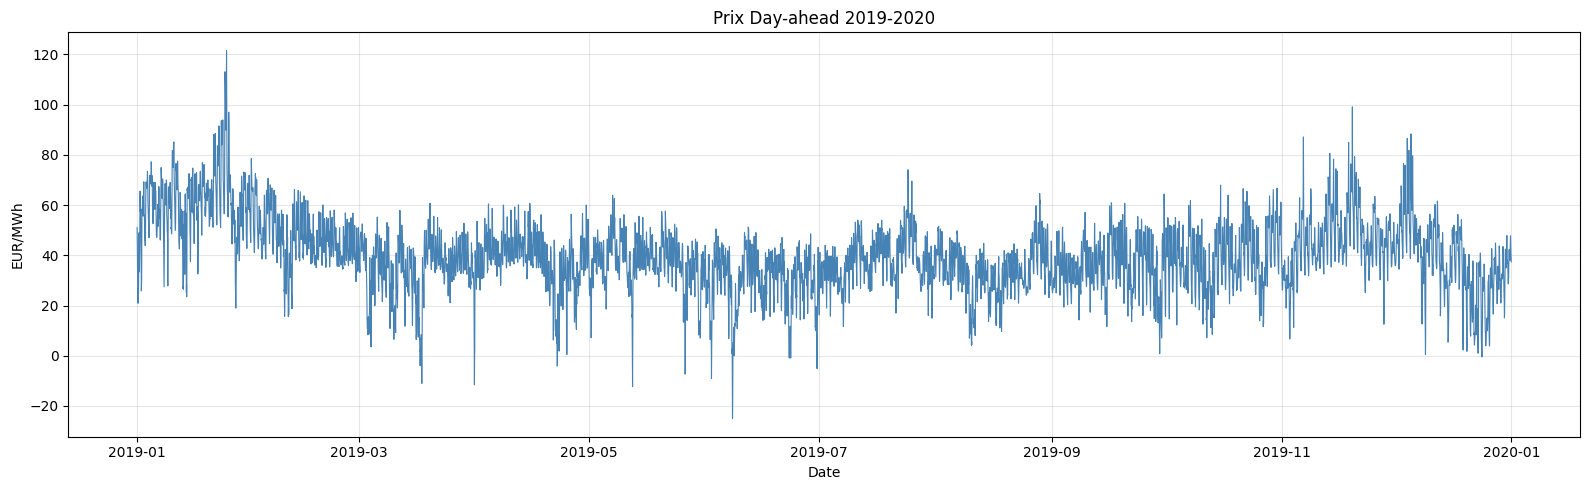

In [7]:
def clean_previous_data_prices(chemin_fichier):
    try:
        df = pd.read_csv(chemin_fichier)
        df = df.rename(columns={"Day-ahead Price [EUR/MWh]": "Day-ahead Price (EUR/MWh)"})
        df = df.drop(columns=[c for c in ["BZN|FR", "Currency", "MTU (CET/CEST)"] if c in df.columns])

        # Conversion du prix en float et suppression des NaN
        df["Day-ahead Price (EUR/MWh)"] = pd.to_numeric(df["Day-ahead Price (EUR/MWh)"], errors='coerce')
        df = df.dropna(subset=["Day-ahead Price (EUR/MWh)"]).reset_index(drop=True)

        # Détecter l'année de début depuis le nom du fichier
        annee_debut = os.path.basename(chemin_fichier).split("_")[-1][:4]

        # Générer les dates UTC
        df["Date_start"] = pd.date_range(start=f"{annee_debut}-01-01 00:00:00", periods=len(df), freq="h", tz="UTC")
        df["Date_end"]   = pd.date_range(start=f"{annee_debut}-01-01 01:00:00", periods=len(df), freq="h", tz="UTC")

        df = df[["Date_start", "Date_end", "Day-ahead Price (EUR/MWh)"]]

    except Exception as e:
        print("Erreur :", e)
        return None

    nom_fichier = os.path.basename(chemin_fichier)
    nb_manquants = df.isnull().sum()
    if nb_manquants.any():
        print(f"[{nom_fichier}] ⚠️  Valeurs manquantes :")
        print(nb_manquants[nb_manquants > 0])
    else:
        print(f"[{nom_fichier}] ✅ Aucune valeur manquante.")

    nb_doublons = df.duplicated(subset='Date_start').sum()
    print(f"Doublons : {nb_doublons}")
    print(f"Dimensions : {df.shape}")

    return df

path2 = "./Data/Day-ahead Prices_2019-2020.csv"
df_clean2 = clean_previous_data_prices(path2)
print(df_clean2["Day-ahead Price (EUR/MWh)"].describe())
print(f"Date min : {df_clean2['Date_start'].min()}")
print(f"Date max : {df_clean2['Date_start'].max()}")



plt.figure(figsize=(16, 5))
plt.plot(df_clean2["Date_start"], df_clean2["Day-ahead Price (EUR/MWh)"], linewidth=0.8, color="steelblue")
plt.title("Prix Day-ahead 2019-2020")
plt.ylabel("EUR/MWh")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [3]:

# Marie : Prix de l'énergie sur le marché SPOT
def clean_data_price (chemin_fichier):
    df = pd.read_csv(chemin_fichier)
    if df["BZN|FR"].isna().all(): # on vérifie que la colonne est vide avant de la supprimer
        df = df.drop(columns=["BZN|FR"])
        print('La colonne "BZN|FR" était vide et a été supprimée.')
    else:
        print('La colonne "BZN|FR" contient des données.')
    df=df.drop(columns=["Currency"])
    df[["Date_start", "Date_end"]] = df["MTU (CET/CEST)"].str.split(" - ", expand=True) 
    df = df.drop(columns=["MTU (CET/CEST)"]) # on supprime l'ancienne colonne de la plage horaire
    df["Date_start"] = pd.to_datetime(df["Date_start"], format="%d.%m.%Y %H:%M", utc = True).dt.tz_localize(None) # on change de le format de la date de début et de fin
    df["Date_end"] = pd.to_datetime(df["Date_end"], format="%d.%m.%Y %H:%M", utc = True).dt.tz_localize(None) # on change de le format de la date de fin
    print(df.shape)
    print(df.head())
    return df
#clean_data_price(".\Data\Day-ahead Prices_2019-2020.csv")



Nettoyage des données de température

In [ ]:
# Marine : Température & pseudo rayonnement
def clean_data_temperature (chemin_fichier): 
    fichier = pd.read_csv(chemin_fichier, sep=";")
    fichier["Horodate"] = pd.to_datetime(fichier["Horodate"], utc = True)
    fichier = fichier.drop(columns=["Année-Mois-Jour"])
    fichier = fichier.drop(columns = ["Année"])
    fichier = fichier.drop(columns = ["Mois"])
    fichier = fichier.drop(columns = ["Jour"])
    print(fichier.isna().sum())
    print(fichier.isnull().sum() )
    print(fichier.duplicated().sum())
    print(fichier.info())
    print(fichier.head())
    print(fichier.describe()) 
    return fichier

  

Nettoyage des données de Prévision J-1

In [ ]:
def clean_eco2mix(chemin_fichier):
    try:
        df = pd.read_csv(chemin_fichier, sep='\t', encoding='latin-1', engine='python')
        df.columns = df.columns.str.strip()
        print(f"Dimensions initiales : {df.shape}")
    except Exception as e:
        print("Erreur lors de la lecture :", e)
        return None

    try:
        df = df[["Date", "Heures", "Prévision J-1"]].copy()

        # Conversion en numérique (les NaN et "ND" deviennent NaN)
        df["Prévision J-1"] = pd.to_numeric(df["Prévision J-1"], errors='coerce')

        # Créer un index horaire : regrouper par tranche de 4 lignes (00, 15, 30, 45)
        df = df.dropna(subset=["Date"]).reset_index(drop=True)
        df["groupe"] = df.index // 4

        # Sommer les 4 quarts d'heure par heure
        df_agg = df.groupby("groupe")["Prévision J-1"].sum().reset_index(drop=True)

        # Détecter l'année depuis le nom du fichier
        annee = os.path.basename(chemin_fichier).split("_")[-1][:4]

        # Générer le calendrier UTC
        dates = pd.date_range(start=f"{annee}-01-01 00:00:00", periods=len(df_agg), freq="h", tz="UTC")

        df_final = pd.DataFrame({
            "Date_start"    : dates,
            "Date_end"      : dates + pd.Timedelta("1h"),
            "Prévision J-1" : df_agg.values
        })

    except Exception as e:
        print("Erreur lors du traitement :", e)
        return None

    nom_fichier = os.path.basename(chemin_fichier)

    nb_manquants = df_final.isnull().sum()
    if nb_manquants.any():
        print(f"[{nom_fichier}] ⚠️  Valeurs manquantes :")
        print(nb_manquants[nb_manquants > 0])
    else:
        print(f"[{nom_fichier}] ✅ Aucune valeur manquante.")

    nb_doublons = df_final.duplicated(subset='Date_start').sum()
    print(f"Doublons : {nb_doublons}")

    diff = df_final["Date_start"].diff().dropna()
    trous = diff[diff != pd.Timedelta("1h")]
    if len(trous) == 0:
        print(f"[{nom_fichier}] ✅ Série temporelle continue.")
    else:
        print(f"[{nom_fichier}] ⚠️  {len(trous)} trou(s) détecté(s) :")
        print(df_final.loc[trous.index, ["Date_start", "Date_end"]])

    print(f"Dimensions finales : {df_final.shape}")
    return df_final


# Test 
path_eco2mix = "./Data/eCO2mix prod/eCO2mix_RTE_Annuel-Definitif_2019.xls" 
df_eco2mix = clean_eco2mix(path_eco2mix)
print(df_eco2mix.head())


# print(f"Format détecté : {os.path.splitext(path_eco2mix)[1]}")

# with open(path_eco2mix, 'rb') as f:
#     debut = f.read(8)
# if debut.startswith(b'\xd0\xcf\x11\xe0'):
#     print("Format : Excel binaire (.xls réel)")
# elif debut.startswith(b'PK'):
#     print("Format : Excel moderne (.xlsx)")
# else:
#     print(f"Format : Texte (CSV/TSV déguisé en .xls) - premiers octets : {debut}")

# # for enc in ['utf-8', 'utf-8-sig', 'latin-1', 'ISO-8859-1', 'Windows-1252']:
# #     try:
# #         df = pd.read_csv(path_eco2mix, sep='\t', encoding=enc, nrows=5)
# #         print(f"✅ Encodage {enc} fonctionne :")
# #         print(df.columns.tolist())
# #         break
# #     except Exception as e:
# #         print(f"❌ {enc} : {e}")


Dimensions initiales : (35041, 40)
[eCO2mix_RTE_Annuel-Definitif_2019.xls] ✅ Aucune valeur manquante.
Doublons : 0
[eCO2mix_RTE_Annuel-Definitif_2019.xls] ✅ Série temporelle continue.
Dimensions finales : (0, 3)
Empty DataFrame
Columns: [Date_start, Date_end, Prévision J-1]
Index: []


Création d'un dataframe avec l'ensemble des data "day ahead prices" depuis 2019


Période : 2019-2020
[Day-ahead Prices_2019-2020.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
  Lignes     : 8760
  Date min   : 2019-01-01 00:00:00+00:00
  Date max   : 2019-12-31 23:00:00+00:00

Période : 2020-2021
[Day-ahead Prices_2020-2021.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8784, 3)
  Lignes     : 8784
  Date min   : 2020-01-01 00:00:00+00:00
  Date max   : 2020-12-31 23:00:00+00:00

Période : 2021-2022
[Day-ahead Prices_2021-2022.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
  Lignes     : 8760
  Date min   : 2021-01-01 00:00:00+00:00
  Date max   : 2021-12-31 23:00:00+00:00

Période : 2022-2023
[Day-ahead Prices_2022-2023.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
  Lignes     : 8760
  Date min   : 2022-01-01 00:00:00+00:00
  Date max   : 2022-12-31 23:00:00+00:00

Période : 2023-2024
[Day-ahead Prices_2023-2024.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
  Ligne

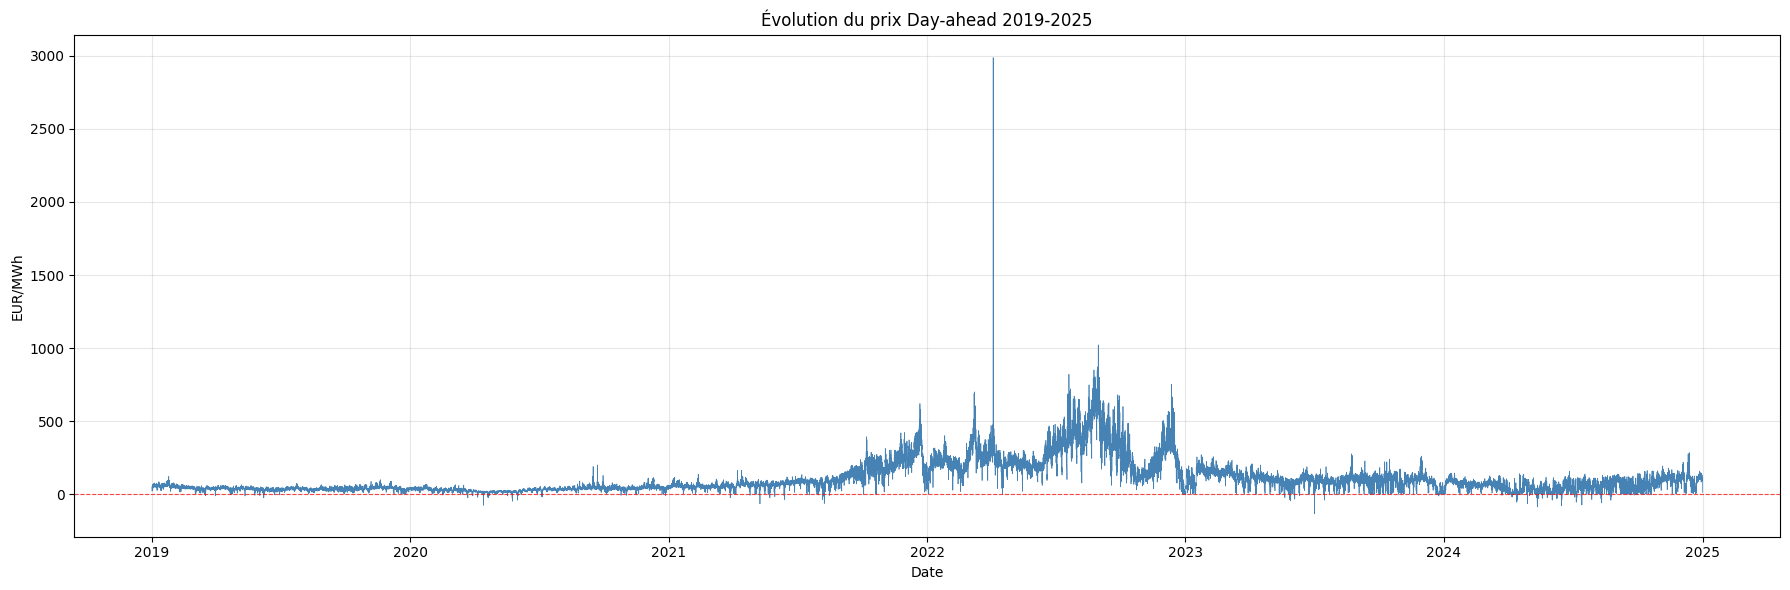

In [ ]:
paths = {
    "2019-2020": "./Data/Day-ahead Prices_2019-2020.csv",
    "2020-2021": "./Data/Day-ahead Prices_2020-2021.csv",
    "2021-2022": "./Data/Day-ahead Prices_2021-2022.csv",
    "2022-2023": "./Data/Day-ahead Prices_2022-2023.csv",
    "2023-2024": "./Data/Day-ahead Prices_2023-2024.csv",
    "2024-2025": "./Data/Day-ahead Prices_2024-2025.csv",
}

dfs = {}

for periode, chemin in paths.items():
    print(f"\n{'='*40}")
    print(f"Période : {periode}")

    if periode == "2024-2025":
        df = harmonize_data_DayAhead_price(chemin)
    else:
        df = clean_previous_data_prices(chemin)

    if df is None:
        print(f"  ⚠️  Échec du chargement pour {periode}")
        continue

    print(f"  Lignes     : {len(df)}")
    print(f"  Date min   : {df['Date_start'].min()}")
    print(f"  Date max   : {df['Date_start'].max()}")

    dfs[periode] = df

# Concaténation
print(f"\n{'='*40}")
print("Concaténation de tous les DataFrames...")

df_all = pd.concat(dfs.values())

print(f"Dimensions totales : {df_all.shape}")
print(f"Valeurs manquantes :\n{df_all.isnull().sum().to_string()}")
nb_doublons = df_all.duplicated(subset='Date_start').sum()
print(f"Doublons           : {nb_doublons}")
if nb_doublons > 0:
    print(df_all[df_all.duplicated(subset='Date_start', keep=False)].sort_values("Date_start"))
print(df_all.head())

print(df_all["Day-ahead Price (EUR/MWh)"].describe())

# Graphique evolution des prix
df_plot = df_all.sort_values("Date_start").dropna(subset=["Date_start", "Day-ahead Price (EUR/MWh)"])

plt.figure(figsize=(18, 6))
plt.plot(df_plot["Date_start"], df_plot["Day-ahead Price (EUR/MWh)"], linewidth=0.5, color="steelblue")
plt.title("Évolution du prix Day-ahead 2019-2025")
plt.ylabel("EUR/MWh")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)

# Ligne horizontale à 0 pour repérer les prix négatifs
plt.axhline(y=0, color='red', linewidth=0.8, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Code marie: prédiction vent

In [55]:
#import des bibliothèques
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold

2021 : 17520 lignes | 2021-01-01 00:00:00 → 2021-12-31 23:30:00
2022 : 17520 lignes | 2022-01-01 00:00:00 → 2022-12-31 23:30:00
2023 : 17520 lignes | 2023-01-01 00:00:00 → 2023-12-31 23:30:00
Après fusion : 13127 lignes
dict_keys(['Régression linéaire', 'Random Forest', 'Gradient Boosting'])

Modèle : Régression linéaire
  R² train          : 0.6664
  R² test           : 0.6060  ✓ Bon équilibre train/test
  RMSE              : 29208.94 MWh
  MAE               : 20727.31 MWh
  CV R² moyen       : 0.5354
  CV écart-type     : 0.1877
  CV R² par pli     : [np.float64(0.575), np.float64(0.711), np.float64(0.171), np.float64(0.611), np.float64(0.61)]
dict_keys(['Régression linéaire', 'Random Forest', 'Gradient Boosting'])

Modèle : Random Forest
  R² train          : 0.9204
  R² test           : 0.5742  ⚠ Overfitting détecté
  RMSE              : 30366.26 MWh
  MAE               : 21541.90 MWh
  CV R² moyen       : 0.4965
  CV écart-type     : 0.1901
  CV R² par pli     : [np.float64(0.465)

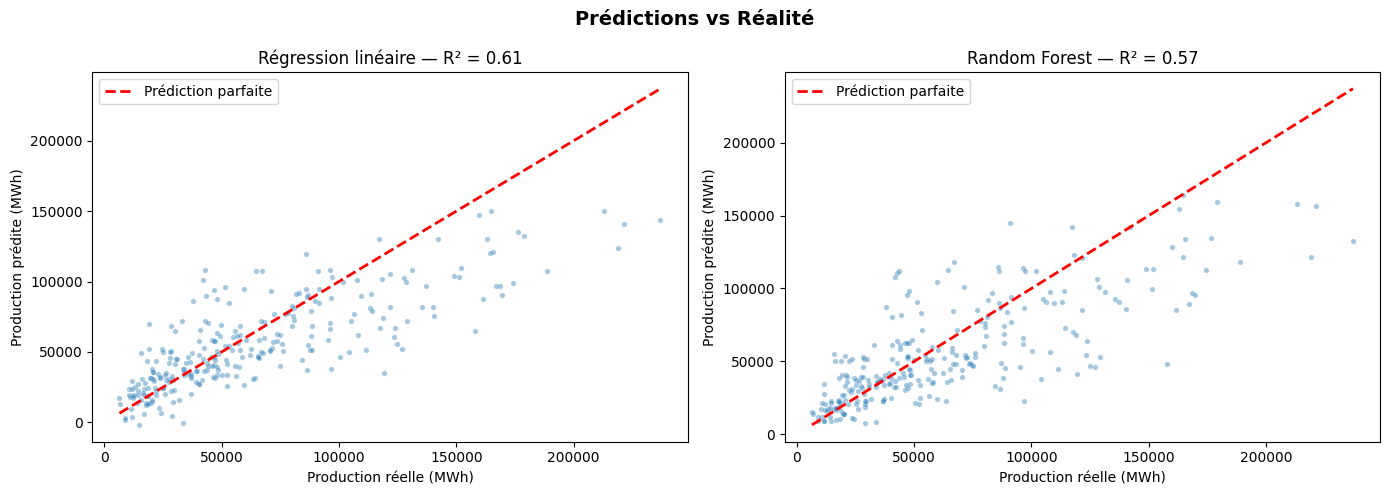

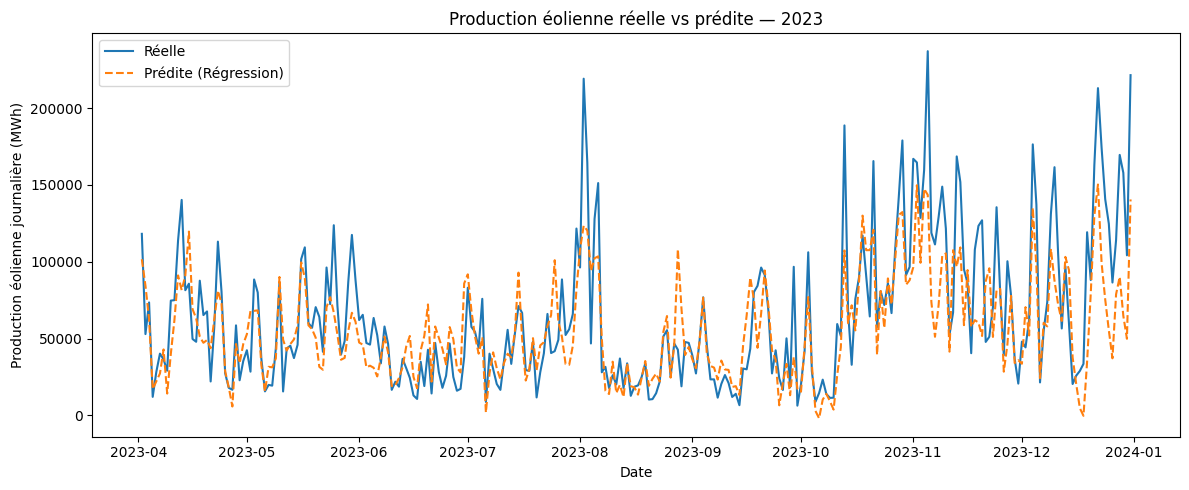


Nombre de jours : 1095
{'r2_train': 0.882460168038763, 'r2_test': 0.5496695957522402, 'rmse': np.float64(31226.922868096524), 'mae': 22286.109031202115, 'cv_mean': np.float64(0.48043289522861626), 'cv_std': np.float64(0.19231330335921779), 'y_pred': array([115912.93583931,  70857.89295788,  53787.26869067,  20516.38344256,
        47327.01731631,  25395.63149718,  38345.11431913,  16171.14690683,
        49190.01135253,  55965.7828066 ,  94061.97741445,  69739.11058304,
       114028.2957978 , 122248.07160857,  58061.80923251,  63156.37117212,
        38995.8606001 ,  43782.66704082,  47128.94645926,  60116.60009876,
        69799.08000275,  84827.95762557,  59241.33005668,  28797.59399168,
        20426.11920435,  12220.96477137,  53878.73295904,  28639.42068222,
        40758.16943799,  52317.88999312,  53674.62300471,  63383.72772255,
        70122.82141402,  23281.07704282,  17579.15612562,  32574.0521464 ,
        26498.44557891,  62680.05107001,  76784.72274987,  56445.55938859,

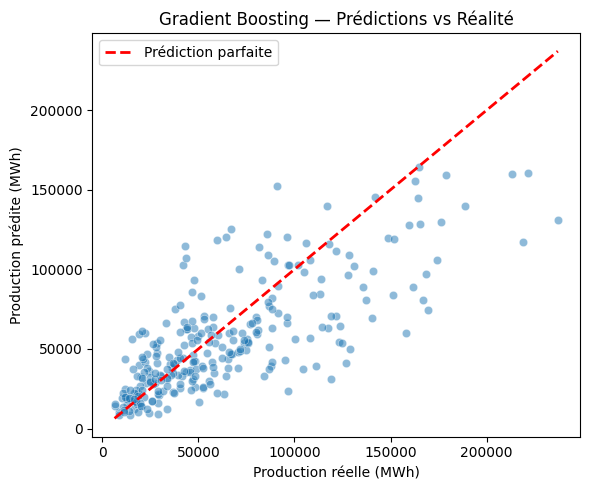

Graphique 3 sauvegardé


<Figure size 640x480 with 0 Axes>

In [62]:
#Nettoyage des données de vents
def donnee_vent():
    df_vent = pd.read_csv(f"data/vent_openmeteo_2021_2023.csv", sep=",")
    print("Shape du fichier :", df_vent.shape)
    print(df_vent.head())
    df_vent["timestamp"] = pd.to_datetime(df_vent["timestamp"])
    df_vent = df_vent[df_vent["timestamp"].dt.minute.isin([0, 30])].reset_index(drop=True)
    print(f"Vent : {len(df_vent)} mesures | {df_vent['timestamp'].min()} → {df_vent['timestamp'].max()}")
    return donnee_vent

#données températures
def donnees_temp():
    donnees_temp = {
        "temperature": {}, 
        "rayonnement": {}, 
        "delta_temperature": {},
        "vent":        {}, 
        "timestamp":   {}
    }
    annees = [2021, 2022, 2023]
    for annee in annees:
        df_temp = pd.read_csv(f"data/donnees-de-temperature-et-de-pseudo-rayonnement_{annee}.csv", sep=";")
        df_temp = df_temp.iloc[::2].reset_index(drop=True)
        
        df_temp["timestamp"] = pd.to_datetime(df_temp["Horodate"], utc=True).dt.tz_convert("Europe/Paris").dt.tz_localize(None)
        # Température normale
        donnees_temp["temperature"][annee] = df_temp["Température normale lissée (°C)"]
        #donnees_temp["temperature"][annee] = df_temp["Température réalisée lissée (°C)"]
        # Delta de température
        donnees_temp["delta_temperature"][annee] = df_temp["Température réalisée lissée - Température normale lissée (°C)"]
        donnees_temp["rayonnement"][annee]  = df_temp["Pseudo rayonnement (%)"]
        donnees_temp["timestamp"][annee]    = df_temp["timestamp"]
    return donnees_temp


# Données de production
def donnees_prod():
    donnees_prod = {
        "eolien":    {},
        "pv":        {},
        "hydro":     {},
        "timestamp": {}
    }
    annees = [2021, 2022, 2023]
    for annee in annees:
        df = pd.read_csv(
            f"Data/eCO2mix prod/eCO2mix_RTE_Annuel-Definitif_{annee}.xls",
            sep="\t",
            encoding="latin-1",
            low_memory=False,
            index_col=False
        )
        df = df[df["Heures"].astype(str).str.match(r"^\d{2}:(00|30)$")].reset_index(drop=True)
        df["timestamp"] = pd.to_datetime(
            df["Date"].astype(str).str.strip() + " " + df["Heures"].astype(str).str.strip(),
            errors="coerce"
        )
        df = df.dropna(subset=["timestamp"]).reset_index(drop=True)
        print(f"{annee} : {len(df)} lignes | {df['timestamp'].min()} → {df['timestamp'].max()}")
        donnees_prod["eolien"][annee]    = pd.to_numeric(df["Eolien"],      errors="coerce").reset_index(drop=True)
        donnees_prod["pv"][annee]        = pd.to_numeric(df["Solaire"],     errors="coerce").reset_index(drop=True)
        donnees_prod["hydro"][annee]     = pd.to_numeric(df["Hydraulique"], errors="coerce").reset_index(drop=True)
        donnees_prod["timestamp"][annee] = df["timestamp"].reset_index(drop=True)
    return donnees_prod


production = donnees_prod()
dfs = []
donnees_temp_dict = donnees_temp()
dfs_temp = []
for annee in [2021, 2022, 2023]:
    df_prod = pd.DataFrame({
        'timestamp': production['timestamp'][annee].values,
        'eolien':        production['eolien'][annee].values,
    })
    dfs.append(df_prod)
    df_temp = pd.DataFrame({
        "timestamp": donnees_temp_dict["timestamp"][annee].values,
        "delta_temperature": donnees_temp_dict["delta_temperature"][annee].values,
       
    })
    dfs_temp.append(df_temp)

df_temp_all = pd.concat(dfs_temp, ignore_index=True)
df_prod_all = pd.concat(dfs, ignore_index=True)

# ── Fusion ────────────────────────────────────────────────────────────────────
#df_merge = pd.merge(df_vent, df_prod_all, on="timestamp", how="inner")
df_merge = pd.merge(df_vent, df_prod_all, on="timestamp", how="inner")
df_merge = pd.merge(df_merge, df_temp_all, on="timestamp", how="inner")
print(f"Après fusion : {len(df_merge)} lignes")

# ── Agrégation par jour ───────────────────────────────────────────────────────
df_merge["date"] = df_merge["timestamp"].dt.date
df_jour = df_merge.groupby("date").agg(
    eolien_journalier   = ("eolien",               "sum"),
    vent_vitesse_moy = ("vent_vitesse_kmh", "mean"),
    vent_vitesse_std = ("vent_vitesse_kmh", "std"),
    vent_vitesse_max = ("vent_vitesse_kmh", "max"),
    vent_vitesse_min = ("vent_vitesse_kmh", "min"),
    temperature_moy=("delta_temperature","mean"),
).reset_index()

df_jour["vent_vitesse_std"] = df_jour["vent_vitesse_std"].fillna(0)
df_jour["date"] = pd.to_datetime(df_jour["date"])

X = df_jour[["vent_vitesse_moy", "vent_vitesse_max","vent_vitesse_min","vent_vitesse_std","temperature_moy"]]
y = df_jour["eolien_journalier"]

# ── Modèles ───────────────────────────────────────────────────────────────────
train_size = int(0.75 * len(df_jour))
X_train, y_train = X[:train_size], y[:train_size]
X_test,  y_test  = X[train_size:], y[train_size:]

modeles = {
    "Régression linéaire": LinearRegression(),
    "Random Forest":       RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
}

resultats = {}
for nom, model in modeles.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test  = r2_score(y_test,  y_pred_test)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae      = mean_absolute_error(y_test, y_pred_test)

        # Cross-validation
    kf     = KFold(n_splits=5, shuffle=False)
    scores = cross_val_score(model, X, y, cv=kf, scoring="r2")
    print(modeles.keys())
    resultats[nom] = {
        "r2_train": r2_train,
        "r2_test":  r2_test,
        "rmse":     rmse,
        "mae":      mae,
        "cv_mean":  scores.mean(),
        "cv_std":   scores.std(),
        "y_pred":   y_pred_test
    }


    # Overfitting / underfitting
    if r2_train - r2_test > 0.1:
        statut = "⚠ Overfitting détecté"
    elif r2_test < 0.4:
        statut = "⚠ Underfitting détecté"
    else:
        statut = "✓ Bon équilibre train/test"


    print(f"\n{'='*45}")
    print(f"Modèle : {nom}")
    print(f"{'='*45}")
    print(f"  R² train          : {r2_train:.4f}")
    print(f"  R² test           : {r2_test:.4f}  {statut}")
    print(f"  RMSE              : {rmse:.2f} MWh")
    print(f"  MAE               : {mae:.2f} MWh")
    print(f"  CV R² moyen       : {scores.mean():.4f}")
    print(f"  CV écart-type     : {scores.std():.4f}")
    print(f"  CV R² par pli     : {[round(s,3) for s in scores]}")

# ── Graphique 1 — Prédictions vs Réalité ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (nom, res) in zip(axes, resultats.items()):
    sns.scatterplot(x=y_test, y=res["y_pred"], alpha=0.4, s=15, ax=ax)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', linewidth=2, label="Prédiction parfaite")
    ax.set_xlabel("Production réelle (MWh)")
    ax.set_ylabel("Production prédite (MWh)")
    ax.set_title(f"{nom} — R² = {res['r2_test']:.2f}")
    ax.legend()

plt.suptitle("Prédictions vs Réalité", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("graph1_predictions.png", dpi=150)
print("\nGraphique 1 sauvegardé")

# ── Graphique 2 — Série temporelle ───────────────────────────────────────────
dates_test = df_jour["date"].iloc[train_size:].values

plt.figure(figsize=(12, 5))
sns.lineplot(x=dates_test, y=y_test.values,
             label="Réelle", linewidth=1.5)
sns.lineplot(x=dates_test, y=resultats["Régression linéaire"]["y_pred"],
             label="Prédite (Régression)", linewidth=1.5, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Production éolienne journalière (MWh)")
plt.title("Production éolienne réelle vs prédite — 2023")
plt.legend()
plt.tight_layout()
plt.savefig("graph2_serie_temporelle.png", dpi=150)
print("Graphique 2 sauvegardé")

plt.show()
print(f"\nNombre de jours : {len(df_jour)}")

# ── Graphique 3 — Gradient Boost ───────────────────────────────────────────
y_pred_gb = resultats["Gradient Boosting"]["y_pred"]
gb_res = resultats["Gradient Boosting"]
print(gb_res)
plt.figure(figsize=(6,5))
sns.scatterplot(x=y_test, y=y_pred_gb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label="Prédiction parfaite")
plt.xlabel("Production réelle (MWh)")
plt.ylabel("Production prédite (MWh)")
plt.title("Gradient Boosting — Prédictions vs Réalité")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("graph3_gradient_boost.png", dpi=150)
print("Graphique 3 sauvegardé")



